<a href="https://colab.research.google.com/github/Setting231105/ProjectHeQTCSDL_QuanLyQuanTraSua/blob/main/Copy_of_Ti%E1%BB%83u_lu%E1%BA%ADn_cu%E1%BB%91i_k%E1%BB%B3_KPDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# New Section

# New Section

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Đọc dữ liệu từ tệp CSV
df = pd.read_csv('/content/drive/MyDrive/KPDL/6-Collected_Hr_data_performances.xls - Full_Employee_Per (1).csv')

# Kiểm tra dữ liệu
print("Dữ liệu mẫu:")
print(df.head())

# Số dòng
print("Số dòng:", df.shape[0])

# Số cột
print("Số cột:", df.shape[1])

NameError: name 'pd' is not defined

In [ ]:
# Đọc dữ liệu từ tệp CSV
df = pd.read_csv('/content/drive/MyDrive/KPDL/6-Collected_Hr_data_performances.xls - Full_Employee_Per (1).csv')

# Kiểm tra dữ liệu
print("Dữ liệu mẫu:")
print(df.head())

Dữ liệu mẫu:
     Number  Age                    Age.1 Gender MaritalStatus  \
0  E1001000   32         Main labor group   Male        Single   
1  E1001006   47  Middle-aged labor group   Male        Single   
2  E1001007   40         Main labor group   Male       Married   
3  E1001009   41  Middle-aged labor group   Male      Divorced   
4  E1001010   60          Old labor group   Male        Single   

   EducationLevel EducationLevel.1 EducationBackground          JobRole  \
0               3         Bachelor           Marketing  Sales Executive   
1               4           Master           Marketing  Sales Executive   
2               4           Master       Life Sciences  Sales Executive   
3               4           Master     Human Resources          Manager   
4               4           Master           Marketing  Sales Executive   

   EnvironmentSatisfaction  ... RelationshipSatisfaction  \
0                        4  ...                        4   
1                  

In [ ]:
# Kiểm tra giá trị thiếu
print("\nKiểm tra giá trị thiếu:")
print(df.isnull().sum())


Kiểm tra giá trị thiếu:
Number                            0
Age                               0
Age.1                             0
Gender                            0
MaritalStatus                     0
EducationLevel                    0
EducationLevel.1                  0
EducationBackground               0
JobRole                           0
EnvironmentSatisfaction           0
EnvironmentSatisfaction.1         0
RelationshipSatisfaction          0
RelationshipSatisfaction.1        0
WorkLifeBalance                   0
WorkLifeBalance.1                 0
TotalWorkExperienceInYears        0
TotalWorkExperienceInYears.1      0
ExperienceYearsInCurrentRole      0
ExperienceYearsInCurrentRole.1    0
PerformanceRating                 0
PerformanceResult                 0
dtype: int64


In [ ]:
# Loại bỏ cột dư thừa or trùng lặp
df = df.drop(columns=['Age.1', 'EducationLevel.1', 'WorkLifeBalance.1', 'RelationshipSatisfaction.1', 'EnvironmentSatisfaction.1', 'TotalWorkExperienceInYears.1', 'ExperienceYearsInCurrentRole.1'], errors='ignore')


In [ ]:
print("Số cột sau khi xóa:", df.shape[1])


Số cột sau khi xóa: 14


In [ ]:
print("Các cột còn lại:")
print(df.columns.tolist())


Các cột còn lại:
['Number', 'Age', 'Gender', 'MaritalStatus', 'EducationLevel', 'EducationBackground', 'JobRole', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance', 'TotalWorkExperienceInYears', 'ExperienceYearsInCurrentRole', 'PerformanceRating', 'PerformanceResult']


In [ ]:
print("Dữ liệu mẫu sau khi xóa cột:")
print(df.head())


Dữ liệu mẫu sau khi xóa cột:
     Number  Age Gender MaritalStatus  EducationLevel EducationBackground  \
0  E1001000   32   Male        Single               3           Marketing   
1  E1001006   47   Male        Single               4           Marketing   
2  E1001007   40   Male       Married               4       Life Sciences   
3  E1001009   41   Male      Divorced               4     Human Resources   
4  E1001010   60   Male        Single               4           Marketing   

           JobRole  EnvironmentSatisfaction  RelationshipSatisfaction  \
0  Sales Executive                        4                         4   
1  Sales Executive                        4                         4   
2  Sales Executive                        4                         3   
3          Manager                        2                         2   
4  Sales Executive                        1                         4   

   WorkLifeBalance  TotalWorkExperienceInYears  ExperienceYearsInCurr

In [ ]:
df_encoded = df_encoded.drop(columns=['Number'])



In [ ]:
# Lưu lại bản đã làm sạch
df_cleaned = df.copy()


In [ ]:
# Mã hóa dữ liệu phân loại
from sklearn.preprocessing import LabelEncoder


df_encoded = df.copy()
label_cols = ['Gender', 'MaritalStatus', 'EducationBackground', 'JobRole', 'PerformanceResult']

for col in label_cols:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])



In [ ]:
print("Dữ liệu sau khi mã hóa:")
print(df_encoded[categorical_cols].head())


Dữ liệu sau khi mã hóa:
   Gender  MaritalStatus  EducationBackground  JobRole  PerformanceResult
0       1              2                    2       13                  2
1       1              2                    2       13                  2
2       1              1                    1       13                  1
3       1              0                    0        8                  2
4       1              2                    2       13                  2


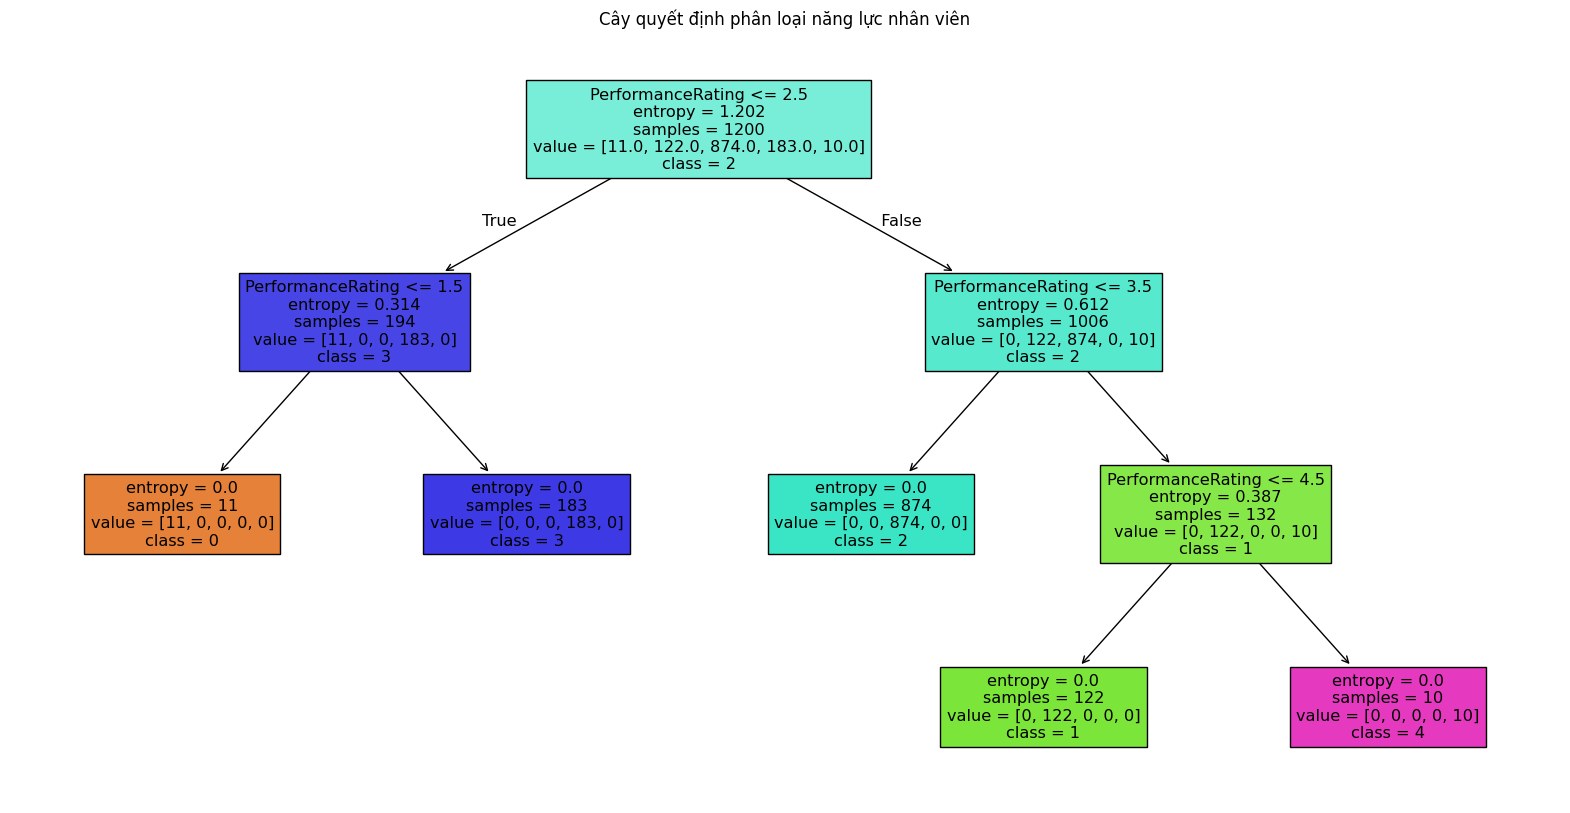

In [ ]:
# Vẽ cây
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

features = [
    'Age', 'Gender', 'MaritalStatus', 'EducationLevel',
    'EducationBackground', 'JobRole', 'EnvironmentSatisfaction',
    'RelationshipSatisfaction', 'WorkLifeBalance',
    'TotalWorkExperienceInYears', 'ExperienceYearsInCurrentRole',
    'PerformanceRating'
]
target = 'PerformanceResult'

X = df_encoded[features]
y = df_encoded[target]

clf = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
clf.fit(X, y)

class_names = [str(cls) for cls in clf.classes_]
plt.figure(figsize=(20, 10))
plot_tree(clf,
          feature_names=features,
          class_names=class_names,
          filled=True)
plt.title("Cây quyết định phân loại năng lực nhân viên")
plt.show()



In [ ]:
print(df_encoded.dtypes)


Number                          object
Age                              int64
Gender                           int64
MaritalStatus                    int64
EducationLevel                   int64
EducationBackground              int64
JobRole                          int64
EnvironmentSatisfaction          int64
RelationshipSatisfaction         int64
WorkLifeBalance                  int64
TotalWorkExperienceInYears       int64
ExperienceYearsInCurrentRole     int64
PerformanceRating                int64
PerformanceResult                int64
dtype: object


In [ ]:
#Xuất cây dưới dạng văn bản
from sklearn.tree import export_text

tree_rules = export_text(clf, feature_names=features)
print(tree_rules)


|--- PerformanceRating <= 2.50
|   |--- PerformanceRating <= 1.50
|   |   |--- class: 0
|   |--- PerformanceRating >  1.50
|   |   |--- class: 3
|--- PerformanceRating >  2.50
|   |--- PerformanceRating <= 3.50
|   |   |--- class: 2
|   |--- PerformanceRating >  3.50
|   |   |--- PerformanceRating <= 4.50
|   |   |   |--- class: 1
|   |   |--- PerformanceRating >  4.50
|   |   |   |--- class: 4



In [ ]:
# Dự đoán trên tập kiểm tra
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)


In [ ]:
# Tính độ chính xác
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Độ chính xác của mô hình cây quyết định:", round(accuracy * 100, 2), "%")


Độ chính xác của mô hình cây quyết định: 100.0 %


In [ ]:
# Báo cáo phân loại
from sklearn.metrics import classification_report

print("Báo cáo phân loại:")
print(classification_report(y_test, y_pred))


Báo cáo phân loại:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00        26
           2       1.00      1.00      1.00       184
           3       1.00      1.00      1.00        27
           4       1.00      1.00      1.00         1

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



In [ ]:
# Vẽ biểu đồ tương quan giữa các đặc trưng
#Chọn các cột số
numeric_cols = [
    'Age', 'EducationLevel', 'EnvironmentSatisfaction',
    'RelationshipSatisfaction', 'WorkLifeBalance',
    'TotalWorkExperienceInYears', 'ExperienceYearsInCurrentRole',
    'PerformanceRating'
]


In [ ]:
#Tính ma trận tương quan
correlation_matrix = df_encoded[numeric_cols].corr()


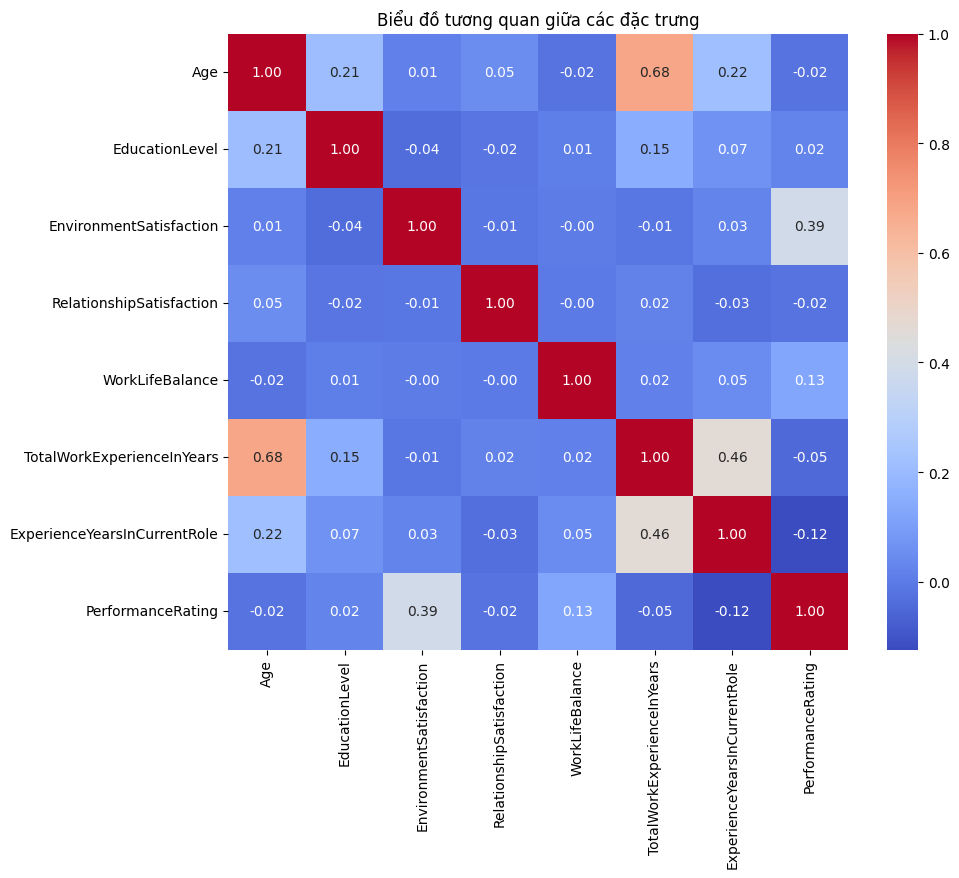

In [ ]:
#Vẽ
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Biểu đồ tương quan giữa các đặc trưng")
plt.show()


In [ ]:
# Tính ma trận nhầm lẫn
from sklearn.metrics import confusion_matrix

# Dự đoán trên tập kiểm tra
y_pred = clf.predict(X_test)

# Tính ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)
print("Ma trận nhầm lẫn:")
print(cm)


Ma trận nhầm lẫn:
[[  2   0   0   0   0]
 [  0  26   0   0   0]
 [  0   0 184   0   0]
 [  0   0   0  27   0]
 [  0   0   0   0   1]]


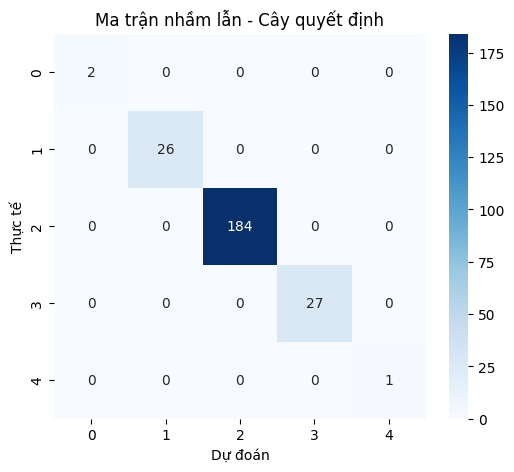

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Dự đoán trên tập kiểm tra
y_pred = clf.predict(X_test)

# Tính ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)

# Vẽ biểu đồ ma trận nhầm lẫn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Ma trận nhầm lẫn - Cây quyết định')
plt.show()



Độ chính xác Naive Bayes: 100.0 %
Ma trận nhầm lẫn:
[[  2   0   0   0   0]
 [  0  26   0   0   0]
 [  0   0 184   0   0]
 [  0   0   0  27   0]
 [  0   0   0   0   1]]
Báo cáo phân loại:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00        26
           2       1.00      1.00      1.00       184
           3       1.00      1.00      1.00        27
           4       1.00      1.00      1.00         1

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



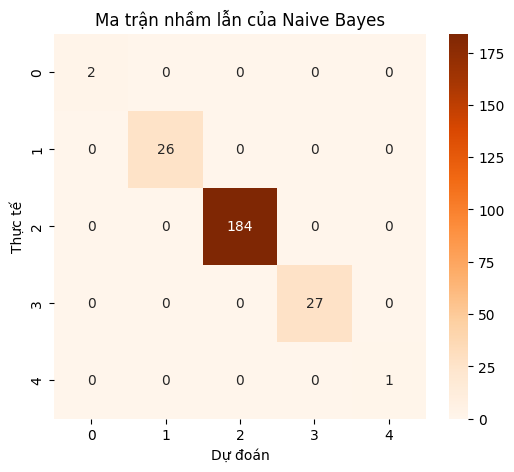

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Khởi tạo mô hình
nb = GaussianNB()

# Huấn luyện mô hình
nb.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred_nb = nb.predict(X_test)

# Độ chính xác
print("Độ chính xác Naive Bayes:", round(accuracy_score(y_test, y_pred_nb) * 100, 2), "%")

# Ma trận nhầm lẫn
print("Ma trận nhầm lẫn:")
print(confusion_matrix(y_test, y_pred_nb))

# Báo cáo phân loại
print("Báo cáo phân loại:")
print(classification_report(y_test, y_pred_nb))

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Dự đoán trên tập kiểm tra
y_pred_nb = nb.predict(X_test)

# Tính ma trận nhầm lẫn
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Vẽ biểu đồ ma trận nhầm lẫn
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges', xticklabels=nb.classes_, yticklabels=nb.classes_)
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Ma trận nhầm lẫn của Naive Bayes')
plt.show()



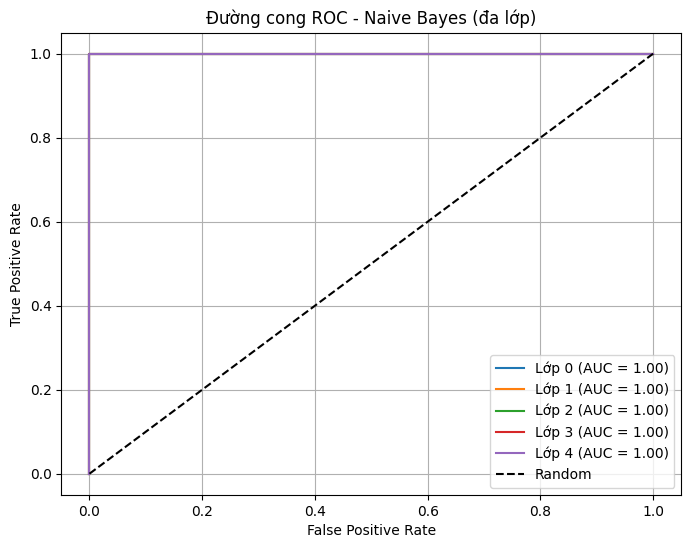

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import RocCurveDisplay

# Binarize nhãn đầu ra
y_bin = label_binarize(y, classes=[0, 1, 2, 3, 4])
n_classes = y_bin.shape[1]

# Chia tập huấn luyện và kiểm tra
X_train, X_test, y_train_bin, y_test_bin = train_test_split(X, y_bin, test_size=0.2, random_state=42)

# Huấn luyện mô hình one-vs-rest
classifier = OneVsRestClassifier(GaussianNB())
y_score = classifier.fit(X_train, y_train_bin).predict_proba(X_test)

# Vẽ đường ROC cho từng lớp
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Lớp {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Đường cong ROC - Naive Bayes (đa lớp)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


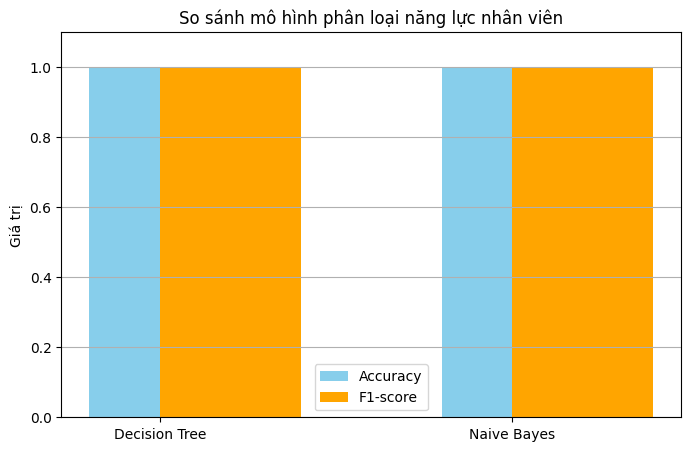

In [ ]:
import matplotlib.pyplot as plt

# Giá trị đánh giá mô hình
models = ['Decision Tree', 'Naive Bayes']
accuracy = [1.00, 1.00]  # Độ chính xác
f1_score = [1.00, 1.00]  # F1-score

x = range(len(models))

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))
plt.bar(x, accuracy, width=0.4, label='Accuracy', align='center', color='skyblue')
plt.bar(x, f1_score, width=0.4, label='F1-score', align='edge', color='orange')

plt.xticks(x, models)
plt.ylim(0.0, 1.1)
plt.ylabel('Giá trị')
plt.title('So sánh mô hình phân loại năng lực nhân viên')
plt.legend()
plt.grid(axis='y')
plt.show()


/tmp/ipython-input-49984562.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=performance_counts.index, y=performance_counts.values, palette='viridis')


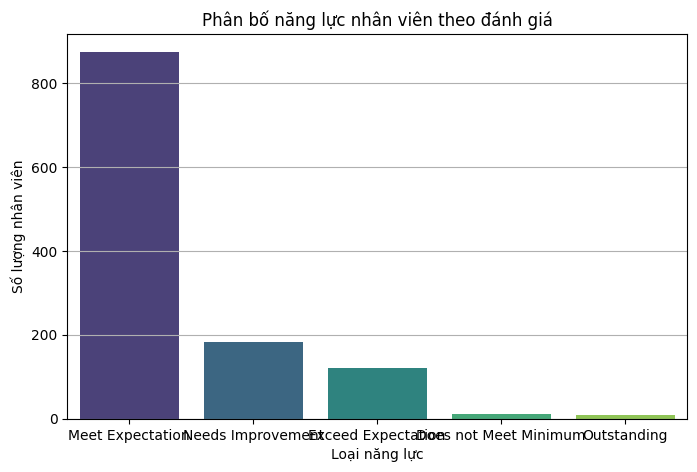

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# Đếm số lượng nhân viên theo từng loại năng lực
performance_counts = df['PerformanceResult'].value_counts()

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))
sns.barplot(x=performance_counts.index, y=performance_counts.values, palette='viridis')
plt.xlabel('Loại năng lực')
plt.ylabel('Số lượng nhân viên')
plt.title('Phân bố năng lực nhân viên theo đánh giá')
plt.grid(axis='y')
plt.show()


 Độ chính xác Random Forest: 99.58 %
 Báo cáo phân loại:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       0.96      1.00      0.98        26
           2       1.00      1.00      1.00       184
           3       1.00      1.00      1.00        27
           4       0.00      0.00      0.00         1

    accuracy                           1.00       240
   macro avg       0.79      0.80      0.80       240
weighted avg       0.99      1.00      0.99       240



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


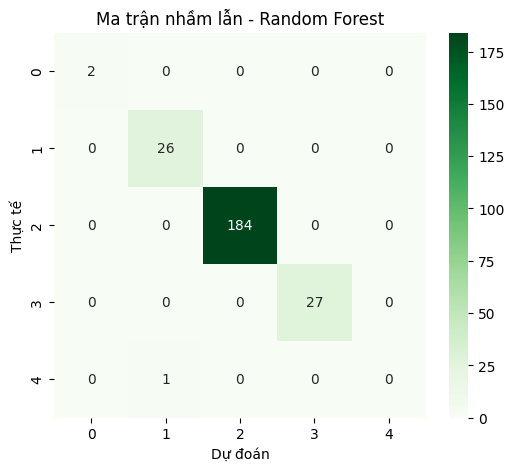

In [ ]:
# Mô hình cải tiến
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Khởi tạo mô hình Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)

# Huấn luyện mô hình
rf_model.fit(X_train, y_train)

# Dự đoán
y_pred_rf = rf_model.predict(X_test)

# Đánh giá mô hình
print(" Độ chính xác Random Forest:", round(accuracy_score(y_test, y_pred_rf) * 100, 2), "%")
print(" Báo cáo phân loại:")
print(classification_report(y_test, y_pred_rf))

# Vẽ ma trận nhầm lẫn
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Ma trận nhầm lẫn - Random Forest')
plt.show()


 Độ chính xác XGBoost: 100.0 %
Báo cáo phân loại:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00        26
           2       1.00      1.00      1.00       184
           3       1.00      1.00      1.00        27
           4       1.00      1.00      1.00         1

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



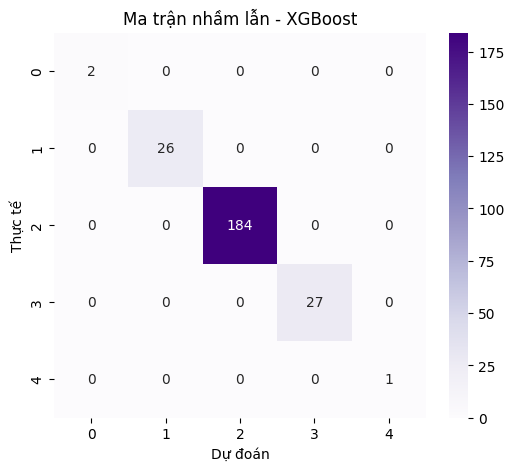

In [ ]:
## Mô hình cải tiến
#Cài đặt thư viện nếu chưa có
!pip install xgboost

# Import thư viện
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Khởi tạo mô hình XGBoost
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',  # Phân loại đa lớp
    num_class=5,                # Số lớp đầu ra
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    random_state=42
)

# Huấn luyện mô hình
xgb_model.fit(X_train, y_train)

# Dự đoán
y_pred_xgb = xgb_model.predict(X_test)

# Đánh giá mô hình
print(" Độ chính xác XGBoost:", round(accuracy_score(y_test, y_pred_xgb) * 100, 2), "%")
print("Báo cáo phân loại:")
print(classification_report(y_test, y_pred_xgb))

# Vẽ ma trận nhầm lẫn
import seaborn as sns
import matplotlib.pyplot as plt

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples', xticklabels=xgb_model.classes_, yticklabels=xgb_model.classes_)
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Ma trận nhầm lẫn - XGBoost')
plt.show()
